### Import & Setup

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np

from skimage.feature import hog, local_binary_pattern
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.cluster import MiniBatchKMeans

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

print("✅ Libraries imported.")


✅ Libraries imported.


### Path

In [2]:
base_dir = Path("/kaggle/input/flowerdatasets/flowers")
train_dir = base_dir / "train"
val_dir   = base_dir / "val"
test_dir  = base_dir / "test"

class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
print("Classes:", class_names)

Classes: ['daisy', 'dandelion', 'lily', 'orchid', 'rose', 'sunflower', 'tulip']


### RootSIFT extractor

In [3]:
sift = cv2.SIFT_create()

def extract_rootsift_descriptors(img_gray, max_kp=500):
    """
    img_gray: ảnh grayscale (ndarray)
    """
    keypoints, desc = sift.detectAndCompute(img_gray, None)
    if desc is None:
        return None

    if desc.shape[0] > max_kp:
        desc = desc[:max_kp]
        
     # ======= RootSIFT =======
    desc = desc.astype("float32")
    # 1) L1 normalize từng descriptor
    desc /= (desc.sum(axis=1, keepdims=True) + 1e-7)
    # 2) Căn bậc hai từng phần tử
    desc = np.sqrt(desc)

    return desc

### Thu thập SIFT descriptor từ train & train codebook (BoVW)

In [4]:
def collect_descriptors_from_train(train_folder, max_images_per_class=250):
    all_desc = []
    train_folder = Path(train_folder)

    for cls in class_names:
        cls_dir = train_folder / cls
        img_files = []
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            img_files.extend(cls_dir.glob(ext))

        img_files = img_files[:max_images_per_class]
        print(f"[Collect] {cls}: {len(img_files)} images")
        
        for img_path in img_files:
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            img_gray = cv2.cvtColor(cv2.resize(img, (256, 256)), cv2.COLOR_BGR2GRAY)
            desc = extract_rootsift_descriptors(img_gray)
            if desc is not None:
                all_desc.append(desc)

    if not all_desc:
        return None

    all_desc = np.vstack(all_desc)
    return all_desc


all_desc = collect_descriptors_from_train(train_dir, max_images_per_class=250)
print("All descriptors shape:", all_desc.shape)

[Collect] daisy: 250 images
[Collect] dandelion: 250 images
[Collect] lily: 250 images
[Collect] orchid: 250 images
[Collect] rose: 250 images
[Collect] sunflower: 250 images
[Collect] tulip: 250 images
All descriptors shape: (598336, 128)


In [ ]:
# Số "visual words"
K = 700

print(f"Training MiniBatchKMeans with K={K} ...")
kmeans = MiniBatchKMeans(
    n_clusters=K,
    batch_size=2000,
    n_init=10,
    random_state=42,
    verbose=1
)
kmeans.fit(all_desc)
print("Done.")

### Trích HSV histogram + BoVW cho 1 ảnh

In [6]:
def extract_hsv_hist(img_bgr, bins=(4,4,4)):
    """
    HSV 3D histogram (ít bins để tránh quá dài).
    Hellinger (L1 + sqrt).
    """
    img_resized = cv2.resize(img_bgr, (256, 256))
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)

    hist = cv2.calcHist(
        [hsv], [0,1,2], None,
        bins,                       # (H,S,V)
        [0,180, 0,256, 0,256]
    )
    hist = hist.astype("float32")
    hist = hist.flatten()

    # Hellinger cho màu
    hist /= (hist.sum() + 1e-7)
    hist = np.sqrt(hist)
    return hist

def extract_center_hsv_hist(img_bgr, bins=(4,4,4)):
    h, w = img_bgr.shape[:2]
    # cắt ô giữa ảnh (ví dụ 1/2 chiều cao, 1/2 chiều rộng)
    x1, x2 = w//4, 3*w//4
    y1, y2 = h//4, 3*h//4
    center = img_bgr[y1:y2, x1:x2]

    hsv = cv2.cvtColor(center, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv],[0,1,2],None,bins,[0,180,0,256,0,256])
    hist = hist.astype("float32").flatten()
    hist /= (hist.sum() + 1e-7)
    hist = np.sqrt(hist)   # Hellinger
    return hist


In [7]:
def image_to_bovw_hsv(img_path):
    """
    Trả về feature vector = [BoVW_RootSIFT, HSV_hist]
    """
    img = cv2.imread(str(img_path))
    if img is None:
        # fallback vector zeros
        return np.zeros(K + (4*4*4), dtype=np.float32)

    img_resized = cv2.resize(img, (256, 256))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # --- BoVW từ RootSIFT ---
    desc = extract_rootsift_descriptors(gray)
    if desc is None:
        bovw_hist = np.zeros(K, dtype=np.float32)
    else:
        words = kmeans.predict(desc)
        bovw_hist, _ = np.histogram(words, bins=np.arange(K+1))
        bovw_hist = bovw_hist.astype("float32")
        # Hellinger
        bovw_hist /= (bovw_hist.sum() + 1e-7)
        bovw_hist = np.sqrt(bovw_hist)

    # --- HSV color feature ---
    global_hsv = extract_hsv_hist(img_resized, bins=(4,4,4))  # 64 dims
    center_hsv = extract_center_hsv_hist(img_resized, bins=(4,4,4))
    # --- Gộp ---
    feat = np.hstack([bovw_hist, global_hsv, center_hsv])
    return feat

### Load dataset (train / val / test) với BoVW+HSV

In [8]:
def load_bovw_hsv_dataset(folder):
    X, y = [], []
    folder = Path(folder)

    for label, cls in enumerate(class_names):
        cls_dir = folder / cls
        img_files = []
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            img_files.extend(cls_dir.glob(ext))

        print(f"[Load] {folder.name} - {cls}: {len(img_files)} images")

        for img_path in img_files:
            feat = image_to_bovw_hsv(img_path)
            X.append(feat)
            y.append(label)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

X_train, y_train = load_bovw_hsv_dataset(train_dir)
X_val,   y_val   = load_bovw_hsv_dataset(val_dir)
X_test,  y_test  = load_bovw_hsv_dataset(test_dir)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape,   y_val.shape)
print("Test :", X_test.shape,  y_test.shape)


[Load] train - daisy: 1231 images
[Load] train - dandelion: 1046 images
[Load] train - lily: 1132 images
[Load] train - orchid: 1295 images
[Load] train - rose: 1042 images
[Load] train - sunflower: 1199 images
[Load] train - tulip: 1124 images
[Load] val - daisy: 352 images
[Load] val - dandelion: 299 images
[Load] val - lily: 324 images
[Load] val - orchid: 370 images
[Load] val - rose: 298 images
[Load] val - sunflower: 342 images
[Load] val - tulip: 321 images
[Load] test - daisy: 176 images
[Load] test - dandelion: 150 images
[Load] test - lily: 162 images
[Load] test - orchid: 186 images
[Load] test - rose: 149 images
[Load] test - sunflower: 172 images
[Load] test - tulip: 161 images
Train: (8069, 828) (8069,)
Val  : (2306, 828) (2306,)
Test : (1156, 828) (1156,)


### Chuẩn hóa + PCA

In [9]:
print("Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Applying PCA...")
pca = PCA(n_components=192, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Original dim:", X_train_scaled.shape[1])
print("After PCA   :", X_train_pca.shape[1])


Standardizing features...
Applying PCA...
Original dim: 828
After PCA   : 192


### Train SVM 

In [10]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled       = scaler.transform(X_test)

X_train_full_pca = pca.fit_transform(X_train_full_scaled)
X_test_pca       = pca.transform(X_test_scaled)

svm_final = SVC(C=10, gamma='scale', kernel='rbf', random_state=42, probability=True)
svm_final.fit(X_train_full_pca, y_train_full)

SVC(C=10, probability=True, random_state=42)

### Đánh giá 

===== ĐÁNH GIÁ TRÊN TEST SET =====
Test accuracy: 0.8771626297577855

Classification report:
              precision    recall  f1-score   support

       daisy     0.9645    0.9261    0.9449       176
   dandelion     0.9724    0.9400    0.9559       150
        lily     0.8452    0.8765    0.8606       162
      orchid     0.8333    0.8871    0.8594       186
        rose     0.7724    0.7517    0.7619       149
   sunflower     0.9385    0.9767    0.9573       172
       tulip     0.8092    0.7640    0.7859       161

    accuracy                         0.8772      1156
   macro avg     0.8765    0.8746    0.8751      1156
weighted avg     0.8775    0.8772    0.8769      1156



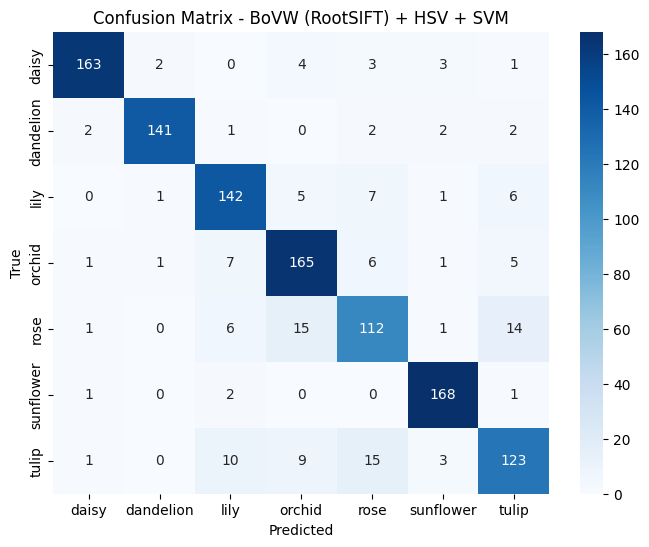

In [11]:
# Test set
test_pred = svm_final.predict(X_test_pca)
test_acc = accuracy_score(y_test, test_pred)
print("===== ĐÁNH GIÁ TRÊN TEST SET =====")
print("Test accuracy:", test_acc)
print("\nClassification report:")
print(classification_report(y_test, test_pred, target_names=class_names, zero_division=0, digits=4))

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - BoVW (RootSIFT) + HSV + SVM")
plt.show()

### Dự đoán với một ảnh bất kì

In [12]:
def predict_image(img_path: str):
    feats = image_to_bovw_hsv(img_path)
    feats = feats.reshape(1, -1)
    feats_scaled = scaler.transform(feats)
    feats_pca = pca.transform(feats_scaled)
    pred_idx = svm_final.predict(feats_pca)[0]
    return class_names[pred_idx]

# Ví dụ lấy 1 ảnh bất kỳ từ test set
sample_img_path = '/kaggle/input/test-demo/image42-1660292012-557-width2048height1560.jpg'
print("Sample image:", sample_img_path)

print("Predicted:", predict_image(str(sample_img_path)))

Sample image: /kaggle/input/test-demo/image42-1660292012-557-width2048height1560.jpg
Predicted: tulip


### Lưu file model

In [13]:
# 1. Gom tất cả những thứ cần thiết vào một từ điển (dictionary)
# Lưu luôn class_names để sau này app tự biết tên hoa, không cần gõ lại
model_data = {
    "kmeans": kmeans,           # Để tạo BoVW từ SIFT
    "scaler": scaler,           # Để chuẩn hóa dữ liệu
    "pca": pca,                 # Để giảm chiều dữ liệu
    "model": svm_final,         # Model SVM cuối cùng
    "class_names": class_names, # Danh sách tên các loài hoa
    "K_value": K                # Số lượng cụm K (700)
}

# 2. Lưu xuống đĩa
filename = "bovw_sift_hsv_svm.pkl"
with open(filename, "wb") as f:
    pickle.dump(model_data, f)

print(f"✅ Đã lưu xong file: {filename}")

✅ Đã lưu xong file: bovw_sift_hsv_svm.pkl
